# Avaliação de Desempenho: Poda Estruturada de Camadas (*Layer Pruning*) no AnyGraph

Este notebook avalia o impacto da **Poda Estruturada de Camadas (*Layer Pruning*)** baseada no **Block Influence (BI)** nos modelos pré-treinados do AnyGraph (`pretrain_link1` e `pretrain_link2`), comparando o desempenho do modelo original com as versões reduzidas.

### Configurações Avaliadas:
1. **Modelo Inteiro (Baseline):** 8 camadas ativas por expert (0% de poda — 16.87M parâmetros).
2. **Poda Tier 1 (Conservadora):** Remoção das Camadas **`[5, 6]`** em todos os experts (**-25% de parâmetros** — 12.65M parâmetros).
3. **Poda Tier 2 (Agressiva):** Remoção das Camadas **`[4, 5, 6, 7]`** em todos os experts (**-50% de parâmetros** — 8.43M parâmetros).

### Datasets Oficiais Utilizados:
Utiliza os **5 datasets oficiais de classificação de nós do AnyGraph** (os mesmos do benchmark de *Global Magnitude Pruning*):
- **`arxiv`** (169.383 nós — artigos científicos)
- **`cora`** (25.191 nós — citações acadêmicas)
- **`home`** (9.795 nós — co-compra de produtos domésticos)
- **`pubmed`** (19.720 nós — publicações biomédicas)
- **`tech`** (47.431 nós — co-compra de tecnologia)

In [5]:
import os
import sys
import copy
import torch as t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

# ============================================================
# DIRETÓRIO DO PROJETO
# ============================================================

cwd = os.getcwd()

if os.path.basename(cwd) == "OpenGraph":
    PROJECT_ROOT = cwd

elif os.path.exists(os.path.join(cwd, "OpenGraph")):
    PROJECT_ROOT = os.path.join(cwd, "OpenGraph")

else:
    PROJECT_ROOT = os.path.abspath(".")

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

sys.argv = ["pruning_evaluation"]


# ============================================================
# ARGUMENTOS DO LINK PREDICTION
# ============================================================

from link_prediction.params import args

if t.cuda.is_available():
    args.gpu = "0"
    args.devices = ["cuda:0", "cuda:0"]

    print(
        f"Utilizando Dispositivo: "
        f"{args.devices[0]} (GPU)"
    )

else:
    args.gpu = "-1"
    args.devices = ["cpu", "cpu"]

    print("Utilizando Dispositivo: CPU")


args.tst_mode = "tst"
args.trn_mode = "train-all"
args.shot = 0
args.proj_method = "both"
args.gnn_layer = 3

# Compatibilidade com o checkpoint pretrn_gen0
args.latdim = 1024


# ============================================================
# IMPORTS DO OPENGRAPH
# ============================================================

import link_prediction.Utils.TimeLogger as logger
from link_prediction.Utils.TimeLogger import log

from link_prediction.data_handler import *
import link_prediction.model
from link_prediction.main import *

from Pruning_Methods.layer_pruner import *


# Compatibilidade com checkpoint serializado
sys.modules["model"] = link_prediction.model


# ============================================================
# DIRETÓRIOS DE SAÍDA
# ============================================================

OUT_DIR = os.path.join(
    os.path.abspath(".."),
    "Block_Influence_results",
    "layer_pruning_evaluation"
)

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


# ============================================================
# DATASETS OFICIAIS
# ============================================================

OFFICIAL_LINK_DATASETS = [
    "ml1m",
    "ml10m",
    "collab",
    "ddi",
    "amazon-book",
    "gen0",
    "gen1",
    "gen2"
]

print(
    f"Datasets Oficiais de Avaliação: "
    f"{OFFICIAL_LINK_DATASETS}"
)

print(
    f"Diretório de Resultados: "
    f"{OUT_DIR}"
)

Utilizando Dispositivo: cuda:0 (GPU)
Datasets Oficiais de Avaliação: ['ml1m', 'ml10m', 'collab', 'ddi', 'amazon-book', 'gen0', 'gen1', 'gen2']
Diretório de Resultados: c:\Mestrado\Graph_Pruning\Block_Influence_results\layer_pruning_evaluation


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Pipeline Automatizado de Poda e Avaliação de Desempenho

In [10]:
def run_layer_pruning_experiment(
    model_checkpoint="pretrn_gen0",
    datasets=None,
    repeat_times=10
):
    """
    Executa o experimento de pruning baseado em Block Influence
    para a tarefa de link prediction.

    Para cada dataset:
        1. Cria um MultiDataHandler novo
        2. Cria um Exp novo
        3. Avalia o Baseline
        4. Calcula Block Influence
        5. Tier 1: remove 1 camada com menor BI
        6. Tier 2: remove 2 camadas com menor BI
        7. Avalia cada configuração para N=20 e N=40
        8. Repete cada avaliação repeat_times vezes

    Métricas:
        - Recall@20
        - Recall@40
        - NDCG@20
        - NDCG@40
    """

    # ============================================================
    # DATASETS
    # ============================================================

    if datasets is None:
        datasets = OFFICIAL_LINK_DATASETS

    results = []

    # ============================================================
    # CONFIGURAÇÃO DO MODELO
    # ============================================================

    args.load_model = model_checkpoint

    # Compatibilidade com o checkpoint utilizado
    args.latdim = 1024

    # ============================================================
    # LOOP PRINCIPAL
    # UM EXP NOVO PARA CADA DATASET
    # ============================================================

    for dataset_name in datasets:

        print("\n" + "=" * 70)
        print(f"DATASET: {dataset_name}")
        print("=" * 70)

        # --------------------------------------------------------
        # Criar handler NOVO para este dataset
        # --------------------------------------------------------

        handler_data = MultiDataHandler(
            [dataset_name],
            [dataset_name]
        )

        # Criar Exp NOVO
        exp = Exp(handler_data)
        exp.prepare_model()

        # Único handler de teste deste dataset
        handler = exp.multi_handler.tst_handlers[0]

        # ========================================================
        # BASELINE
        # ========================================================

        print("\n" + "-" * 70)
        print("BASELINE")
        print("-" * 70)

        # Carregar modelo original
        args.load_model = model_checkpoint
        exp.load_model()

        baseline_results = {}

        # --------------------------------------------------------
        # Avaliar N = 20 e N = 40
        # --------------------------------------------------------

        for topk in [20, 40]:

            args.topk = topk

            recall_values = []
            ndcg_values = []

            print(f"\nBaseline - N = {topk}")

            for repeat in range(repeat_times):

                ret = exp.test_epoch(
                    handler.tst_loader,
                    handler
                )

                recall_values.append(
                    ret["Recall"]
                )

                ndcg_values.append(
                    ret["NDCG"]
                )

            baseline_results[topk] = {
                "Recall_mean": np.mean(recall_values),
                "Recall_std": np.std(recall_values),
                "NDCG_mean": np.mean(ndcg_values),
                "NDCG_std": np.std(ndcg_values)
            }

            print(
                f"Recall@{topk}: "
                f"{baseline_results[topk]['Recall_mean']:.4f} ± "
                f"{baseline_results[topk]['Recall_std']:.4f}"
            )

            print(
                f"NDCG@{topk}:   "
                f"{baseline_results[topk]['NDCG_mean']:.4f} ± "
                f"{baseline_results[topk]['NDCG_std']:.4f}"
            )

            # ----------------------------------------------------
            # Salvar resultado do Baseline
            # ----------------------------------------------------

            results.append({
                "Dataset": dataset_name,
                "Configuração": "Baseline",
                "N": topk,
                "Camadas Removidas": "Nenhuma",
                "Recall_mean": baseline_results[topk]["Recall_mean"],
                "Recall_std": baseline_results[topk]["Recall_std"],
                "NDCG_mean": baseline_results[topk]["NDCG_mean"],
                "NDCG_std": baseline_results[topk]["NDCG_std"]
            })

        # ========================================================
        # CALCULAR BLOCK INFLUENCE
        # ========================================================

        print("\n" + "-" * 70)
        print("BLOCK INFLUENCE")
        print("-" * 70)

        # Recarregar modelo original
        args.load_model = model_checkpoint
        exp.load_model()

        adj = handler.torch_adj
        initial_projector = handler.initial_projector

        if args.cache_adj == 0:
            adj = adj.to(args.devices[0])

        if args.cache_proj == 0:
            initial_projector = initial_projector.to(
                args.devices[0]
            )

        with t.no_grad():

            initial_embeds = initial_projector()

            input_embeds = exp.model.topoEncoder(
                adj,
                initial_embeds
            ).to(args.devices[1])

        # Criar pruner a partir do modelo original
        pruner = BlockInfluenceLayerPruner(
            exp.model
        )

        df_bi = pruner.compute_bi(
            input_embeds,
            angular=False
        )

        print("\nBlock Influence:")
        display(df_bi)

        # --------------------------------------------------------
        # Ranking: menor BI -> maior BI
        # --------------------------------------------------------

        ranking = (
            df_bi
            .sort_values("Block Influence")
            ["Layer"]
            .tolist()
        )

        print(
            "\nRanking das camadas "
            "(menor BI → maior BI):"
        )

        print(ranking)

        # ========================================================
        # TIER 1
        # ========================================================

        layers_t1 = ranking[:1]

        print("\n" + "-" * 70)
        print("TIER 1")
        print(f"Camada removida: {layers_t1}")
        print("-" * 70)

        # --------------------------------------------------------
        # Recarregar modelo ORIGINAL
        # --------------------------------------------------------

        args.load_model = model_checkpoint
        exp.load_model()

        pruner_t1 = BlockInfluenceLayerPruner(
            exp.model
        )

        pruned_model_t1 = (
            pruner_t1.prune_specific_layers(
                layers_t1
            )
        )

        exp.model = pruned_model_t1

        # --------------------------------------------------------
        # Relatório de sparsity
        # --------------------------------------------------------

        report_t1 = pruner_t1.sparsity_report()

        print("\nSparsity report Tier 1:")
        print(report_t1)

        # --------------------------------------------------------
        # Avaliar N = 20 e N = 40
        # --------------------------------------------------------

        t1_results = {}

        for topk in [20, 40]:

            args.topk = topk

            recall_values = []
            ndcg_values = []

            print(f"\nTier 1 - N = {topk}")

            for repeat in range(repeat_times):

                ret = exp.test_epoch(
                    handler.tst_loader,
                    handler
                )

                recall_values.append(
                    ret["Recall"]
                )

                ndcg_values.append(
                    ret["NDCG"]
                )

            t1_results[topk] = {
                "Recall_mean": np.mean(recall_values),
                "Recall_std": np.std(recall_values),
                "NDCG_mean": np.mean(ndcg_values),
                "NDCG_std": np.std(ndcg_values)
            }

            print(
                f"Recall@{topk}: "
                f"{t1_results[topk]['Recall_mean']:.4f} ± "
                f"{t1_results[topk]['Recall_std']:.4f}"
            )

            print(
                f"NDCG@{topk}:   "
                f"{t1_results[topk]['NDCG_mean']:.4f} ± "
                f"{t1_results[topk]['NDCG_std']:.4f}"
            )

            # ----------------------------------------------------
            # Salvar resultado Tier 1
            # ----------------------------------------------------

            results.append({
                "Dataset": dataset_name,
                "Configuração": "Tier 1",
                "N": topk,
                "Camadas Removidas": str(layers_t1),
                "Recall_mean": t1_results[topk]["Recall_mean"],
                "Recall_std": t1_results[topk]["Recall_std"],
                "NDCG_mean": t1_results[topk]["NDCG_mean"],
                "NDCG_std": t1_results[topk]["NDCG_std"]
            })

        # ========================================================
        # TIER 2
        # ========================================================

        layers_t2 = ranking[:2]

        print("\n" + "-" * 70)
        print("TIER 2")
        print(f"Camadas removidas: {layers_t2}")
        print("-" * 70)

        # --------------------------------------------------------
        # Recarregar modelo ORIGINAL
        # --------------------------------------------------------

        args.load_model = model_checkpoint
        exp.load_model()

        pruner_t2 = BlockInfluenceLayerPruner(
            exp.model
        )

        pruned_model_t2 = (
            pruner_t2.prune_specific_layers(
                layers_t2
            )
        )

        exp.model = pruned_model_t2

        # --------------------------------------------------------
        # Relatório de sparsity
        # --------------------------------------------------------

        report_t2 = pruner_t2.sparsity_report()

        print("\nSparsity report Tier 2:")
        print(report_t2)

        # --------------------------------------------------------
        # Avaliar N = 20 e N = 40
        # --------------------------------------------------------

        t2_results = {}

        for topk in [20, 40]:

            args.topk = topk

            recall_values = []
            ndcg_values = []

            print(f"\nTier 2 - N = {topk}")

            for repeat in range(repeat_times):

                ret = exp.test_epoch(
                    handler.tst_loader,
                    handler
                )

                recall_values.append(
                    ret["Recall"]
                )

                ndcg_values.append(
                    ret["NDCG"]
                )

            t2_results[topk] = {
                "Recall_mean": np.mean(recall_values),
                "Recall_std": np.std(recall_values),
                "NDCG_mean": np.mean(ndcg_values),
                "NDCG_std": np.std(ndcg_values)
            }

            print(
                f"Recall@{topk}: "
                f"{t2_results[topk]['Recall_mean']:.4f} ± "
                f"{t2_results[topk]['Recall_std']:.4f}"
            )

            print(
                f"NDCG@{topk}:   "
                f"{t2_results[topk]['NDCG_mean']:.4f} ± "
                f"{t2_results[topk]['NDCG_std']:.4f}"
            )

            # ----------------------------------------------------
            # Salvar resultado Tier 2
            # ----------------------------------------------------

            results.append({
                "Dataset": dataset_name,
                "Configuração": "Tier 2",
                "N": topk,
                "Camadas Removidas": str(layers_t2),
                "Recall_mean": t2_results[topk]["Recall_mean"],
                "Recall_std": t2_results[topk]["Recall_std"],
                "NDCG_mean": t2_results[topk]["NDCG_mean"],
                "NDCG_std": t2_results[topk]["NDCG_std"]
            })

        # ========================================================
        # RESUMO DO DATASET
        # ========================================================

        print("\n" + "=" * 70)
        print(f"RESUMO - {dataset_name}")
        print("=" * 70)

        for topk in [20, 40]:

            print(f"\nN = {topk}")

            print(
                f"Baseline : "
                f"Recall={baseline_results[topk]['Recall_mean']:.4f} ± "
                f"{baseline_results[topk]['Recall_std']:.4f} | "
                f"NDCG={baseline_results[topk]['NDCG_mean']:.4f} ± "
                f"{baseline_results[topk]['NDCG_std']:.4f}"
            )

            print(
                f"Tier 1   : "
                f"Recall={t1_results[topk]['Recall_mean']:.4f} ± "
                f"{t1_results[topk]['Recall_std']:.4f} | "
                f"NDCG={t1_results[topk]['NDCG_mean']:.4f} ± "
                f"{t1_results[topk]['NDCG_std']:.4f} | "
                f"Remove={layers_t1}"
            )

            print(
                f"Tier 2   : "
                f"Recall={t2_results[topk]['Recall_mean']:.4f} ± "
                f"{t2_results[topk]['Recall_std']:.4f} | "
                f"NDCG={t2_results[topk]['NDCG_mean']:.4f} ± "
                f"{t2_results[topk]['NDCG_std']:.4f} | "
                f"Remove={layers_t2}"
            )

    # ============================================================
    # DATAFRAME FINAL
    # ============================================================

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 70)
    print("RESULTADOS FINAIS")
    print("=" * 70)

    display(results_df)

    # ============================================================
    # SALVAR CSV
    # ============================================================

    output_dir = Path(OUT_DIR)

    output_path = output_dir / (
        f"layer_pruning_link_prediction_{model_checkpoint}.csv"
    )

    results_df.to_csv(
        output_path,
        index=False
    )

    print(
        f"\nResultados salvos em:\n{output_path}"
    )

    return results_df

In [3]:
def plot_metric(df, metric, n):

    dados = df[
        df["N"] == n
    ].copy()

    x = np.arange(len(datasets))

    largura = 0.25

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    for i, config in enumerate(configuracoes):

        valores = []

        erros = []

        for dataset in datasets:

            linha = dados[
                (dados["Dataset"] == dataset) &
                (dados["Configuração"] == config)
            ]

            if len(linha) > 0:

                valores.append(
                    linha[f"{metric}_mean"].iloc[0]
                )

                erros.append(
                    linha[f"{metric}_std"].iloc[0]
                )

            else:

                valores.append(np.nan)
                erros.append(0)

        posicoes = (
            x +
            (i - 1) * largura
        )

        ax.bar(
            posicoes,
            valores,
            largura,
            yerr=erros,
            capsize=4,
            label=config
        )

    # ========================================================
    # FORMATAÇÃO
    # ========================================================

    ax.set_xlabel(
        "Dataset",
        fontsize=12
    )

    ax.set_ylabel(
        metric,
        fontsize=12
    )

    ax.set_title(
        f"{metric}@{n} - OpenGraph",
        fontsize=14
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        datasets,
        rotation=30,
        ha="right"
    )

    ax.legend()

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.show()

## 2. Avaliação de Poda de Camadas no Modelo 1 (`pretrn_gen0`)

In [11]:
results_df1 = run_layer_pruning_experiment(
    model_checkpoint="pretrn_gen0",
    datasets=OFFICIAL_LINK_DATASETS,
    repeat_times=10
)
print("=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 1 ===")
display(results_df1)


DATASET: ml1m
Dataset: ml1m, User num: 6040, Item num: 3706, Node num: 9746, Edge num: 720152


c:\Mestrado\Graph_Pruning\OpenGraph\link_prediction\data_handler.py:73: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(col_degree, -0.5), [-1])
c:\Mestrado\Graph_Pruning\OpenGraph\link_prediction\data_handler.py:65: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(degree, -0.5), [-1])


Total params: 25.1904
Trainable params: 25.1904
Non-trainable params: 0.0

----------------------------------------------------------------------
BASELINE
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen0.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen0.his
2026-09-23 20:31:05.320667: Model Loaded

Baseline - N = 20
Recall@20: 0.1174 ± 0.0046: Steps 23/23: recall = 16.68, ndcg = 27.12          
NDCG@20:   0.2072 ± 0.0034

Baseline - N = 40
Recall@40: 0.1774 ± 0.0076: Steps 23/23: recall = 26.07, ndcg = 28.00          
NDCG@40:   0.2085 ± 0.0046

----------------------------------------------------------------------
BLOCK INFLUENCE
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen0.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen0.his


,Layer,Block Influence
0,0,0.184333
1,1,0.054818
2,2,0.112595
3,3,0.299830



Ranking das camadas (menor BI → maior BI):
[1, 2, 0, 3]

----------------------------------------------------------------------
TIER 1
Camada removida: [1]
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen0.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen0.his
2026-09-23 20:31:32.185458: Model Loaded

Sparsity report Tier 1:
{'Total Params Original': 25190400, 'Total Params Pruned': 18892800, 'Params Removed': 6297600, 'Total Sparsity (%)': 25.0}

Tier 1 - N = 20
Recall@20: 0.1542 ± 0.0014: Steps 23/23: recall = 23.58, ndcg = 33.44          
NDCG@20:   0.2394 ± 0.0014

Tier 1 - N = 40
Recall@40: 0.2403 ± 0.0016: Steps 23/23: recall = 38.13, ndcg = 36.49          
NDCG@40:   0.2505 ± 0.0012

----------------------------------------------------------------------
TIER 2
Camadas removidas: [1, 2]
--------------------------------------------------------------------

...

,Layer,Block Influence
0,0,0.028576
1,1,0.011662
2,2,0.022341
3,3,0.056782



Ranking das camadas (menor BI → maior BI):
[1, 2, 0, 3]

----------------------------------------------------------------------
TIER 1
Camada removida: [1]
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen0.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen0.his
2026-09-23 21:22:25.368610: Model Loaded

Sparsity report Tier 1:
{'Total Params Original': 25190400, 'Total Params Pruned': 18892800, 'Params Removed': 6297600, 'Total Sparsity (%)': 25.0}

Tier 1 - N = 20
Recall@20: 0.0093 ± 0.0001: Steps 44/44: recall = 0.33, ndcg = 0.13          
NDCG@20:   0.0045 ± 0.0000

Tier 1 - N = 40
Recall@40: 0.0154 ± 0.0001: Steps 44/44: recall = 3.33, ndcg = 0.79          
NDCG@40:   0.0059 ± 0.0000

----------------------------------------------------------------------
TIER 2
Camadas removidas: [1, 2]
----------------------------------------------------------------------
L

,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.117369,0.004578,0.207213,0.003364
1,ml1m,Baseline,40,Nenhuma,0.177416,0.007595,0.208549,0.004577
2,ml1m,Tier 1,20,[1],0.154176,0.001388,0.239432,0.001385
3,ml1m,Tier 1,40,[1],0.240339,0.001589,0.250536,0.001206
4,ml1m,Tier 2,20,"[1, 2]",0.130850,0.001397,0.214919,0.001484
5,ml1m,Tier 2,40,"[1, 2]",0.212740,0.004979,0.226517,0.004288
6,ml10m,Baseline,20,Nenhuma,0.236670,0.002222,0.270470,0.002750
7,ml10m,Baseline,40,Nenhuma,0.337156,0.001082,0.295726,0.001814
8,ml10m,Tier 1,20,[1],0.231611,0.003057,0.265993,0.003515
9,ml10m,Tier 1,40,[1],0.338496,0.001535,0.295093,0.001868



Resultados salvos em:
c:\Mestrado\Graph_Pruning\Block_Influence_results\layer_pruning_evaluation\layer_pruning_link_prediction_pretrn_gen0.csv
=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 1 ===


,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.117369,0.004578,0.207213,0.003364
1,ml1m,Baseline,40,Nenhuma,0.177416,0.007595,0.208549,0.004577
2,ml1m,Tier 1,20,[1],0.154176,0.001388,0.239432,0.001385
3,ml1m,Tier 1,40,[1],0.240339,0.001589,0.250536,0.001206
4,ml1m,Tier 2,20,"[1, 2]",0.130850,0.001397,0.214919,0.001484
5,ml1m,Tier 2,40,"[1, 2]",0.212740,0.004979,0.226517,0.004288
6,ml10m,Baseline,20,Nenhuma,0.236670,0.002222,0.270470,0.002750
7,ml10m,Baseline,40,Nenhuma,0.337156,0.001082,0.295726,0.001814
8,ml10m,Tier 1,20,[1],0.231611,0.003057,0.265993,0.003515
9,ml10m,Tier 1,40,[1],0.338496,0.001535,0.295093,0.001868


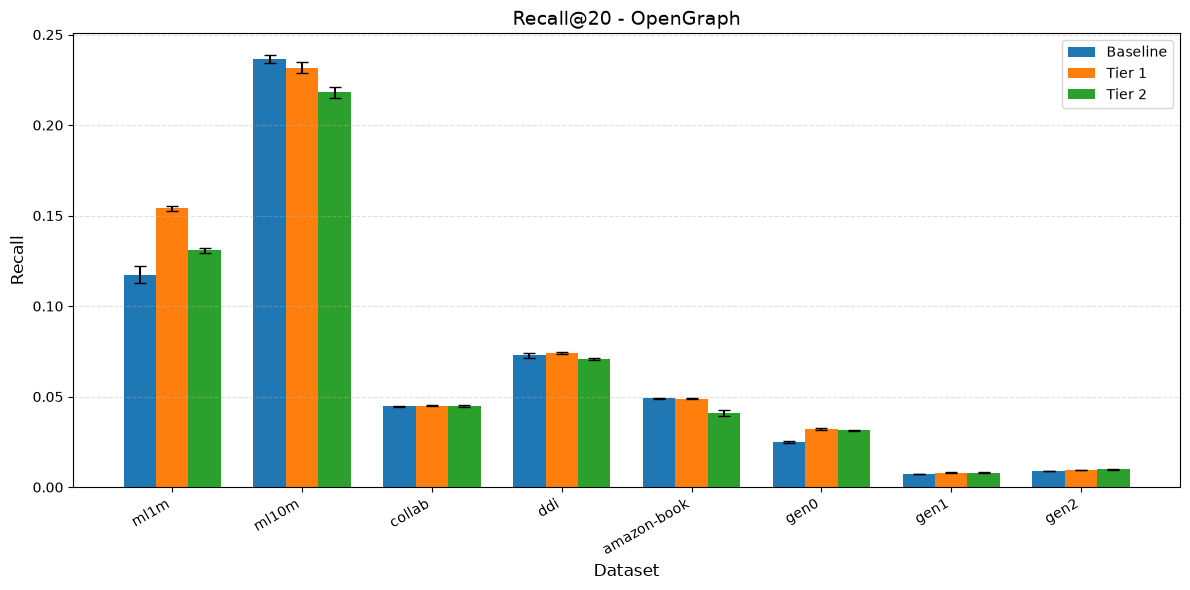

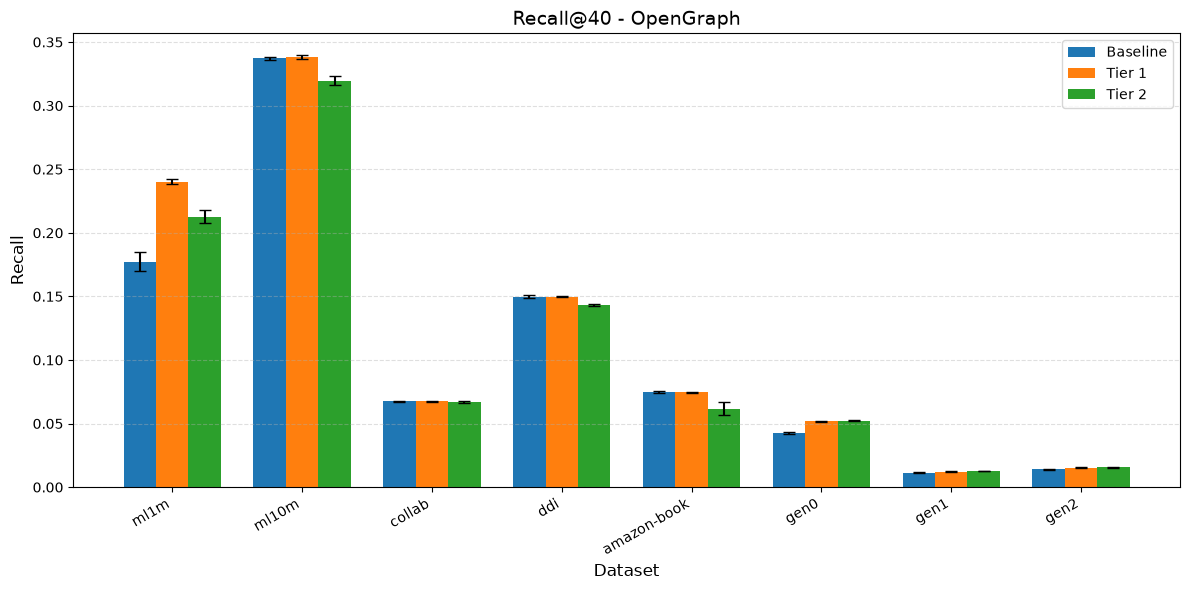

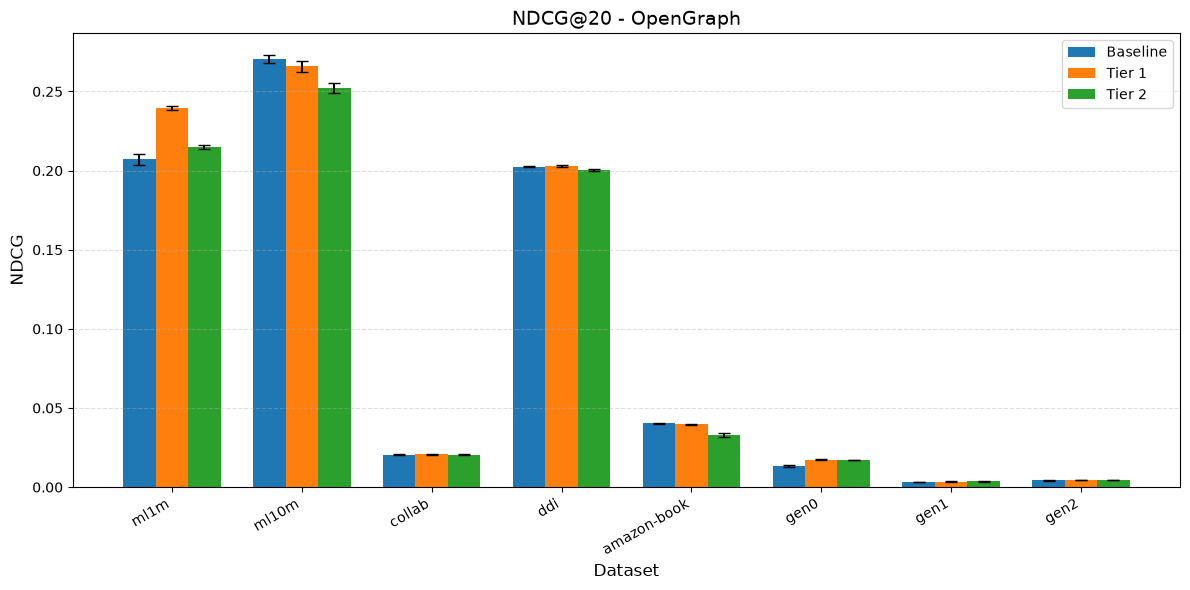

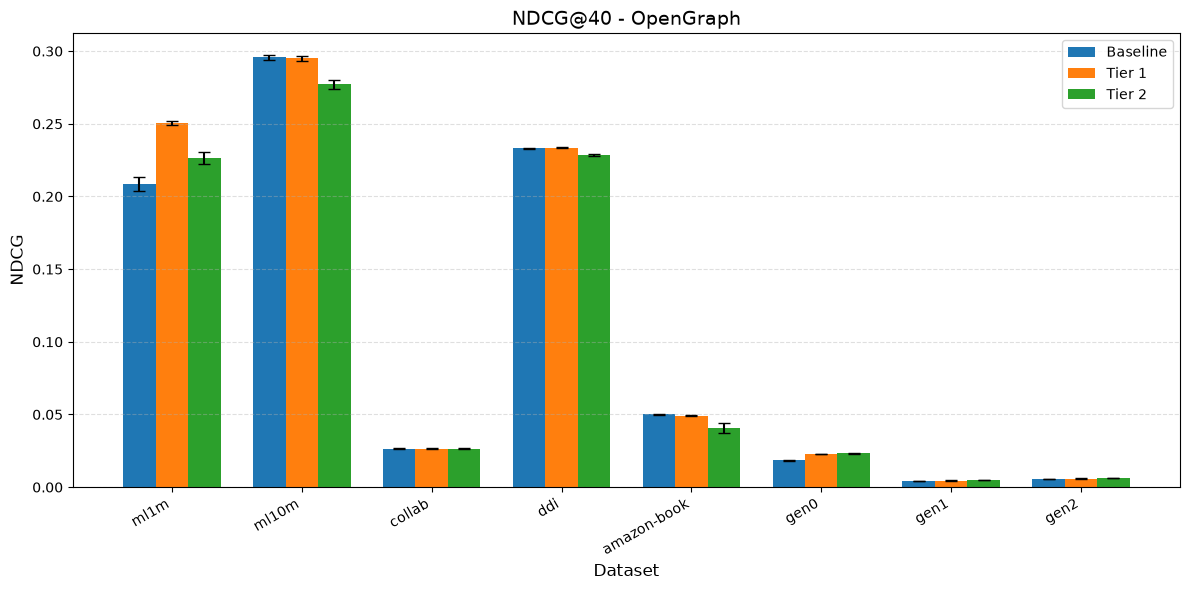

In [5]:
# ============================================================
# PREPARAR DADOS
# ============================================================

df = pd.read_csv("C:\\Mestrado\\Graph_Pruning\\Block_Influence_results\\layer_pruning_evaluation\\layer_pruning_link_prediction_pretrn_gen0.csv")

configuracoes = [
    "Baseline",
    "Tier 1",
    "Tier 2"
]

datasets = df["Dataset"].unique()

# Ordem desejada
df["Configuração"] = pd.Categorical(
    df["Configuração"],
    categories=configuracoes,
    ordered=True
)

df = df.sort_values(
    ["Dataset", "N", "Configuração"]
)


# ============================================================
# GERAR OS 4 GRÁFICOS
# ============================================================

plot_metric(
    df,
    "Recall",
    20
)

plot_metric(
    df,
    "Recall",
    40
)

plot_metric(
    df,
    "NDCG",
    20
)

plot_metric(
    df,
    "NDCG",
    40
)

## 3. Avaliação de Poda de Camadas no Modelo 2 (`pretrn_gen1`)

In [12]:
datasets = [
    "cora",
    "pubmed",
    "citeseer"
]

results_df2 = run_layer_pruning_experiment(
    model_checkpoint="pretrn_gen1",
    datasets=OFFICIAL_LINK_DATASETS,
    repeat_times=10
)
print("=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 2 ===")
display(results_df2)
display(results_df2)


DATASET: ml1m
Dataset: ml1m, User num: 6040, Item num: 3706, Node num: 9746, Edge num: 720152


c:\Mestrado\Graph_Pruning\OpenGraph\link_prediction\data_handler.py:73: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(col_degree, -0.5), [-1])
c:\Mestrado\Graph_Pruning\OpenGraph\link_prediction\data_handler.py:65: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(degree, -0.5), [-1])


Total params: 25.1904
Trainable params: 25.1904
Non-trainable params: 0.0

----------------------------------------------------------------------
BASELINE
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen1.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen1.his
2026-09-23 21:23:20.439632: Model Loaded

Baseline - N = 20
Recall@20: 0.1708 ± 0.0012: Steps 23/23: recall = 26.50, ndcg = 35.69          
NDCG@20:   0.2516 ± 0.0012

Baseline - N = 40
Recall@40: 0.2628 ± 0.0010: Steps 23/23: recall = 42.19, ndcg = 39.26          
NDCG@40:   0.2659 ± 0.0009

----------------------------------------------------------------------
BLOCK INFLUENCE
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen1.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen1.his


,Layer,Block Influence
0,0,0.119368
1,1,0.116991
2,2,0.010145
3,3,0.010404



Ranking das camadas (menor BI → maior BI):
[2, 3, 1, 0]

----------------------------------------------------------------------
TIER 1
Camada removida: [2]
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen1.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen1.his
2026-09-23 21:23:49.839283: Model Loaded

Sparsity report Tier 1:
{'Total Params Original': 25190400, 'Total Params Pruned': 18892800, 'Params Removed': 6297600, 'Total Sparsity (%)': 25.0}

Tier 1 - N = 20
Recall@20: 0.1733 ± 0.0008: Steps 23/23: recall = 28.04, ndcg = 36.67          
NDCG@20:   0.2551 ± 0.0007

Tier 1 - N = 40
Recall@40: 0.2665 ± 0.0009: Steps 23/23: recall = 43.03, ndcg = 39.87          
NDCG@40:   0.2695 ± 0.0007

----------------------------------------------------------------------
TIER 2
Camadas removidas: [2, 3]
--------------------------------------------------------------------

...


Ranking das camadas (menor BI → maior BI):
[3, 2, 1, 0]

----------------------------------------------------------------------
TIER 1
Camada removida: [3]
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen1.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen1.his
2026-09-23 22:19:38.658644: Model Loaded

Sparsity report Tier 1:
{'Total Params Original': 25190400, 'Total Params Pruned': 18892800, 'Params Removed': 6297600, 'Total Sparsity (%)': 25.0}

Tier 1 - N = 20
Recall@20: 0.0104 ± 0.0001: Steps 44/44: recall = 2.08, ndcg = 0.86          
NDCG@20:   0.0051 ± 0.0001

Tier 1 - N = 40
Recall@40: 0.0170 ± 0.0002: Steps 44/44: recall = 4.08, ndcg = 1.28          
NDCG@40:   0.0068 ± 0.0001

----------------------------------------------------------------------
TIER 2
Camadas removidas: [3, 2]
----------------------------------------------------------------------
L

,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.170774,0.001240,0.251636,0.001180
1,ml1m,Baseline,40,Nenhuma,0.262808,0.001035,0.265939,0.000908
2,ml1m,Tier 1,20,[2],0.173349,0.000784,0.255113,0.000657
3,ml1m,Tier 1,40,[2],0.266497,0.000896,0.269489,0.000735
4,ml1m,Tier 2,20,"[2, 3]",0.173568,0.000960,0.256422,0.000937
5,ml1m,Tier 2,40,"[2, 3]",0.272445,0.001607,0.274029,0.001323
6,ml10m,Baseline,20,Nenhuma,0.252969,0.000503,0.284533,0.000495
7,ml10m,Baseline,40,Nenhuma,0.368579,0.000414,0.315324,0.000426
8,ml10m,Tier 1,20,[2],0.250457,0.000661,0.282470,0.000694
9,ml10m,Tier 1,40,[2],0.364846,0.000607,0.312534,0.000744



Resultados salvos em:
c:\Mestrado\Graph_Pruning\Block_Influence_results\layer_pruning_evaluation\layer_pruning_link_prediction_pretrn_gen1.csv
=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 2 ===


,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.170774,0.001240,0.251636,0.001180
1,ml1m,Baseline,40,Nenhuma,0.262808,0.001035,0.265939,0.000908
2,ml1m,Tier 1,20,[2],0.173349,0.000784,0.255113,0.000657
3,ml1m,Tier 1,40,[2],0.266497,0.000896,0.269489,0.000735
4,ml1m,Tier 2,20,"[2, 3]",0.173568,0.000960,0.256422,0.000937
5,ml1m,Tier 2,40,"[2, 3]",0.272445,0.001607,0.274029,0.001323
6,ml10m,Baseline,20,Nenhuma,0.252969,0.000503,0.284533,0.000495
7,ml10m,Baseline,40,Nenhuma,0.368579,0.000414,0.315324,0.000426
8,ml10m,Tier 1,20,[2],0.250457,0.000661,0.282470,0.000694
9,ml10m,Tier 1,40,[2],0.364846,0.000607,0.312534,0.000744


,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.170774,0.001240,0.251636,0.001180
1,ml1m,Baseline,40,Nenhuma,0.262808,0.001035,0.265939,0.000908
2,ml1m,Tier 1,20,[2],0.173349,0.000784,0.255113,0.000657
3,ml1m,Tier 1,40,[2],0.266497,0.000896,0.269489,0.000735
4,ml1m,Tier 2,20,"[2, 3]",0.173568,0.000960,0.256422,0.000937
5,ml1m,Tier 2,40,"[2, 3]",0.272445,0.001607,0.274029,0.001323
6,ml10m,Baseline,20,Nenhuma,0.252969,0.000503,0.284533,0.000495
7,ml10m,Baseline,40,Nenhuma,0.368579,0.000414,0.315324,0.000426
8,ml10m,Tier 1,20,[2],0.250457,0.000661,0.282470,0.000694
9,ml10m,Tier 1,40,[2],0.364846,0.000607,0.312534,0.000744


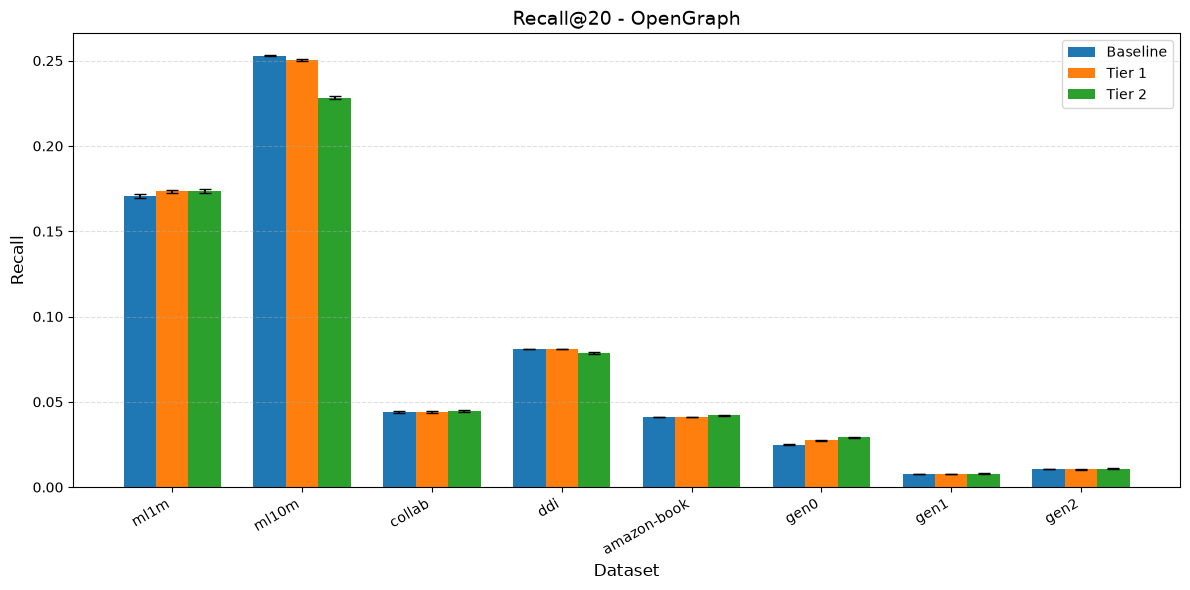

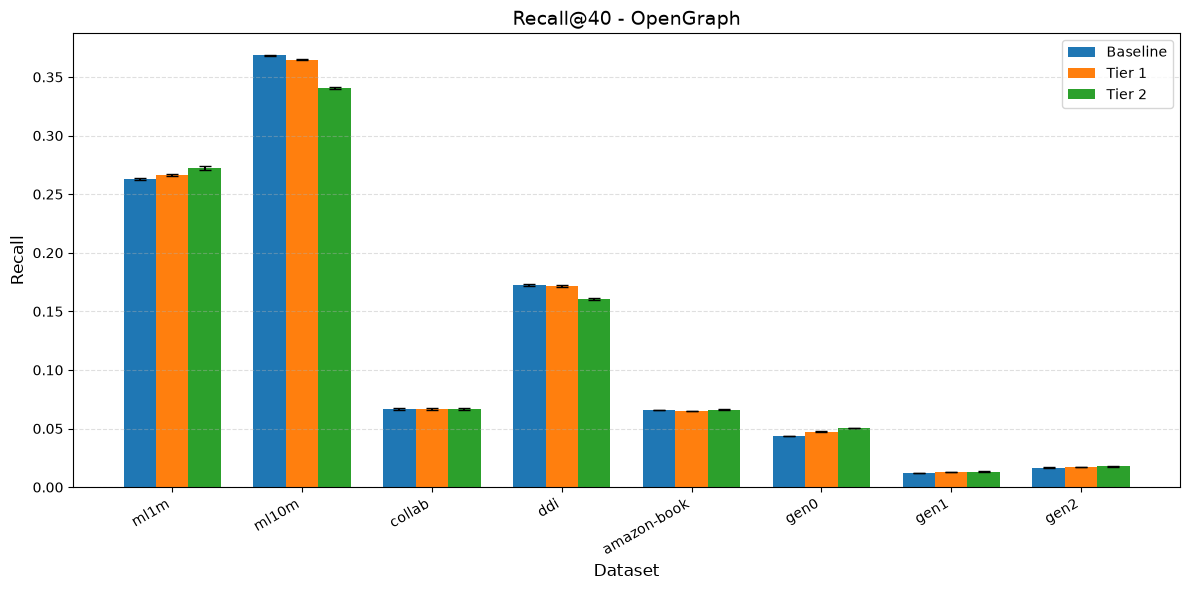

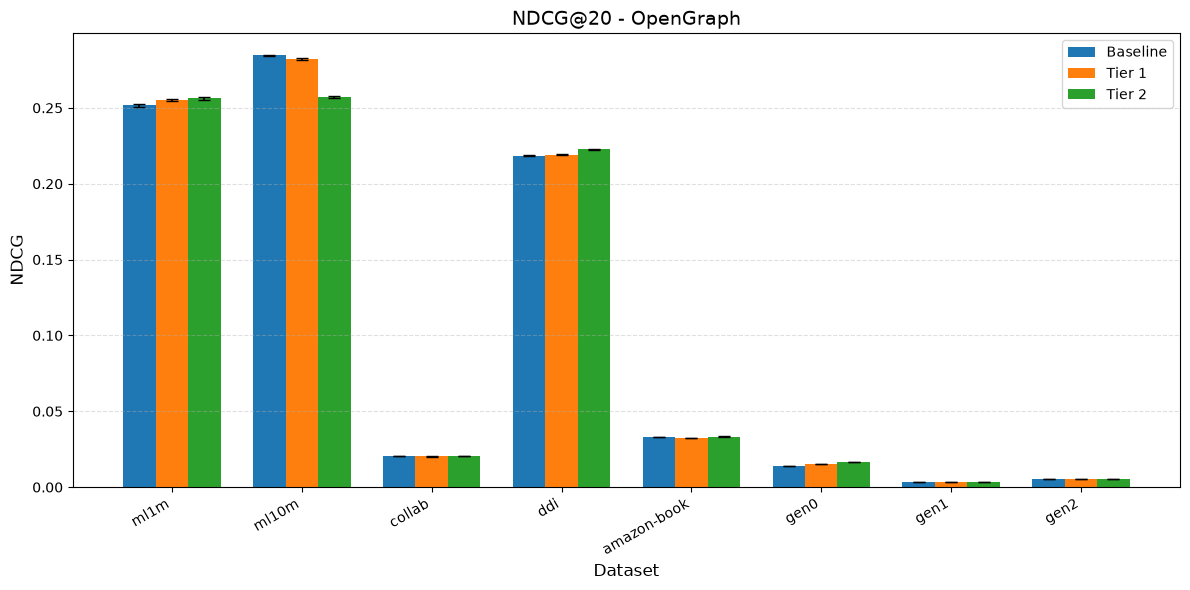

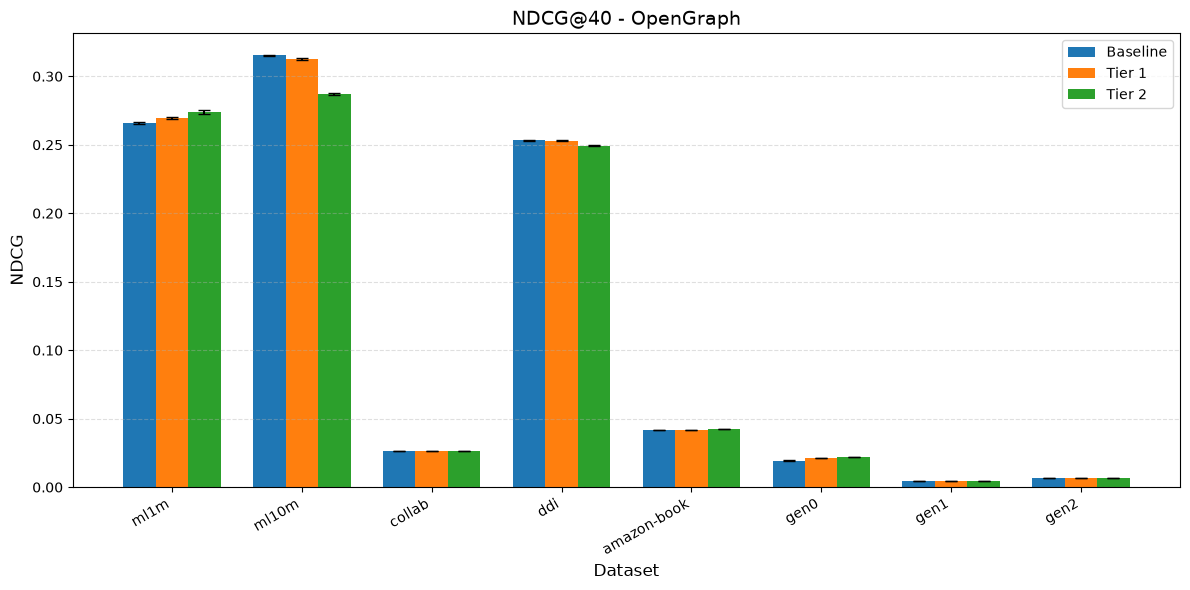

In [6]:
# ============================================================
# PREPARAR DADOS
# ============================================================

df = pd.read_csv("C:\\Mestrado\\Graph_Pruning\\Block_Influence_results\\layer_pruning_evaluation\\layer_pruning_link_prediction_pretrn_gen1.csv")

configuracoes = [
    "Baseline",
    "Tier 1",
    "Tier 2"
]

datasets = df["Dataset"].unique()

# Ordem desejada
df["Configuração"] = pd.Categorical(
    df["Configuração"],
    categories=configuracoes,
    ordered=True
)

df = df.sort_values(
    ["Dataset", "N", "Configuração"]
)


# ============================================================
# GERAR OS 4 GRÁFICOS
# ============================================================

plot_metric(
    df,
    "Recall",
    20
)

plot_metric(
    df,
    "Recall",
    40
)

plot_metric(
    df,
    "NDCG",
    20
)

plot_metric(
    df,
    "NDCG",
    40
)

## 4. Avaliação de Poda de Camadas no Modelo 3 (`pretrn_gen2`)

In [13]:
results_df3 = run_layer_pruning_experiment(
    model_checkpoint="pretrn_gen2",
    datasets=OFFICIAL_LINK_DATASETS,
    repeat_times=10
)
print("=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 3 ===")
display(results_df3)
display(results_df3)


DATASET: ml1m
Dataset: ml1m, User num: 6040, Item num: 3706, Node num: 9746, Edge num: 720152


c:\Mestrado\Graph_Pruning\OpenGraph\link_prediction\data_handler.py:73: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(col_degree, -0.5), [-1])
c:\Mestrado\Graph_Pruning\OpenGraph\link_prediction\data_handler.py:65: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(degree, -0.5), [-1])


Total params: 25.1904
Trainable params: 25.1904
Non-trainable params: 0.0

----------------------------------------------------------------------
BASELINE
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen2.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen2.his
2026-09-23 22:20:28.381687: Model Loaded

Baseline - N = 20
Recall@20: 0.0575 ± 0.0025: Steps 23/23: recall = 10.93, ndcg = 15.79          
NDCG@20:   0.0915 ± 0.0038

Baseline - N = 40
Recall@40: 0.0712 ± 0.0033: Steps 23/23: recall = 13.22, ndcg = 15.11          
NDCG@40:   0.0832 ± 0.0035

----------------------------------------------------------------------
BLOCK INFLUENCE
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen2.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen2.his


,Layer,Block Influence
0,0,0.094371
1,1,0.023303
2,2,0.013485
3,3,0.009802



Ranking das camadas (menor BI → maior BI):
[3, 2, 1, 0]

----------------------------------------------------------------------
TIER 1
Camada removida: [3]
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen2.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen2.his
2026-09-23 22:20:55.438799: Model Loaded

Sparsity report Tier 1:
{'Total Params Original': 25190400, 'Total Params Pruned': 18892800, 'Params Removed': 6297600, 'Total Sparsity (%)': 25.0}

Tier 1 - N = 20
Recall@20: 0.1081 ± 0.0032: Steps 23/23: recall = 19.41, ndcg = 27.02          
NDCG@20:   0.1711 ± 0.0041

Tier 1 - N = 40
Recall@40: 0.1501 ± 0.0055: Steps 23/23: recall = 26.83, ndcg = 27.87          
NDCG@40:   0.1690 ± 0.0053

----------------------------------------------------------------------
TIER 2
Camadas removidas: [3, 2]
--------------------------------------------------------------------

...


Ranking das camadas (menor BI → maior BI):
[3, 2, 1, 0]

----------------------------------------------------------------------
TIER 1
Camada removida: [3]
----------------------------------------------------------------------
Loading model from: c:\Mestrado\Graph_Pruning\OpenGraph\Models\pretrn_gen2.mod
Loading history from: c:\Mestrado\Graph_Pruning\OpenGraph\History\pretrn_gen2.his
2026-09-23 23:23:56.050192: Model Loaded

Sparsity report Tier 1:
{'Total Params Original': 25190400, 'Total Params Pruned': 18892800, 'Params Removed': 6297600, 'Total Sparsity (%)': 25.0}

Tier 1 - N = 20
Recall@20: 0.0110 ± 0.0001: Steps 44/44: recall = 1.08, ndcg = 0.53          
NDCG@20:   0.0052 ± 0.0000

Tier 1 - N = 40
Recall@40: 0.0163 ± 0.0001: Steps 44/44: recall = 3.17, ndcg = 1.07          
NDCG@40:   0.0066 ± 0.0000

----------------------------------------------------------------------
TIER 2
Camadas removidas: [3, 2]
----------------------------------------------------------------------
L

,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.057456,0.002540,0.091472,0.003790
1,ml1m,Baseline,40,Nenhuma,0.071203,0.003303,0.083166,0.003527
2,ml1m,Tier 1,20,[3],0.108107,0.003185,0.171058,0.004119
3,ml1m,Tier 1,40,[3],0.150127,0.005531,0.169042,0.005256
4,ml1m,Tier 2,20,"[3, 2]",0.102830,0.001945,0.168181,0.002543
5,ml1m,Tier 2,40,"[3, 2]",0.138873,0.004159,0.161747,0.004123
6,ml10m,Baseline,20,Nenhuma,0.150443,0.004670,0.159138,0.005074
7,ml10m,Baseline,40,Nenhuma,0.225603,0.005652,0.180620,0.005266
8,ml10m,Tier 1,20,[3],0.195411,0.002108,0.214720,0.002343
9,ml10m,Tier 1,40,[3],0.277441,0.003156,0.235736,0.003108



Resultados salvos em:
c:\Mestrado\Graph_Pruning\Block_Influence_results\layer_pruning_evaluation\layer_pruning_link_prediction_pretrn_gen2.csv
=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 3 ===


,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.057456,0.002540,0.091472,0.003790
1,ml1m,Baseline,40,Nenhuma,0.071203,0.003303,0.083166,0.003527
2,ml1m,Tier 1,20,[3],0.108107,0.003185,0.171058,0.004119
3,ml1m,Tier 1,40,[3],0.150127,0.005531,0.169042,0.005256
4,ml1m,Tier 2,20,"[3, 2]",0.102830,0.001945,0.168181,0.002543
5,ml1m,Tier 2,40,"[3, 2]",0.138873,0.004159,0.161747,0.004123
6,ml10m,Baseline,20,Nenhuma,0.150443,0.004670,0.159138,0.005074
7,ml10m,Baseline,40,Nenhuma,0.225603,0.005652,0.180620,0.005266
8,ml10m,Tier 1,20,[3],0.195411,0.002108,0.214720,0.002343
9,ml10m,Tier 1,40,[3],0.277441,0.003156,0.235736,0.003108


,Dataset,Configuração,N,Camadas Removidas,Recall_mean,Recall_std,NDCG_mean,NDCG_std
0,ml1m,Baseline,20,Nenhuma,0.057456,0.002540,0.091472,0.003790
1,ml1m,Baseline,40,Nenhuma,0.071203,0.003303,0.083166,0.003527
2,ml1m,Tier 1,20,[3],0.108107,0.003185,0.171058,0.004119
3,ml1m,Tier 1,40,[3],0.150127,0.005531,0.169042,0.005256
4,ml1m,Tier 2,20,"[3, 2]",0.102830,0.001945,0.168181,0.002543
5,ml1m,Tier 2,40,"[3, 2]",0.138873,0.004159,0.161747,0.004123
6,ml10m,Baseline,20,Nenhuma,0.150443,0.004670,0.159138,0.005074
7,ml10m,Baseline,40,Nenhuma,0.225603,0.005652,0.180620,0.005266
8,ml10m,Tier 1,20,[3],0.195411,0.002108,0.214720,0.002343
9,ml10m,Tier 1,40,[3],0.277441,0.003156,0.235736,0.003108


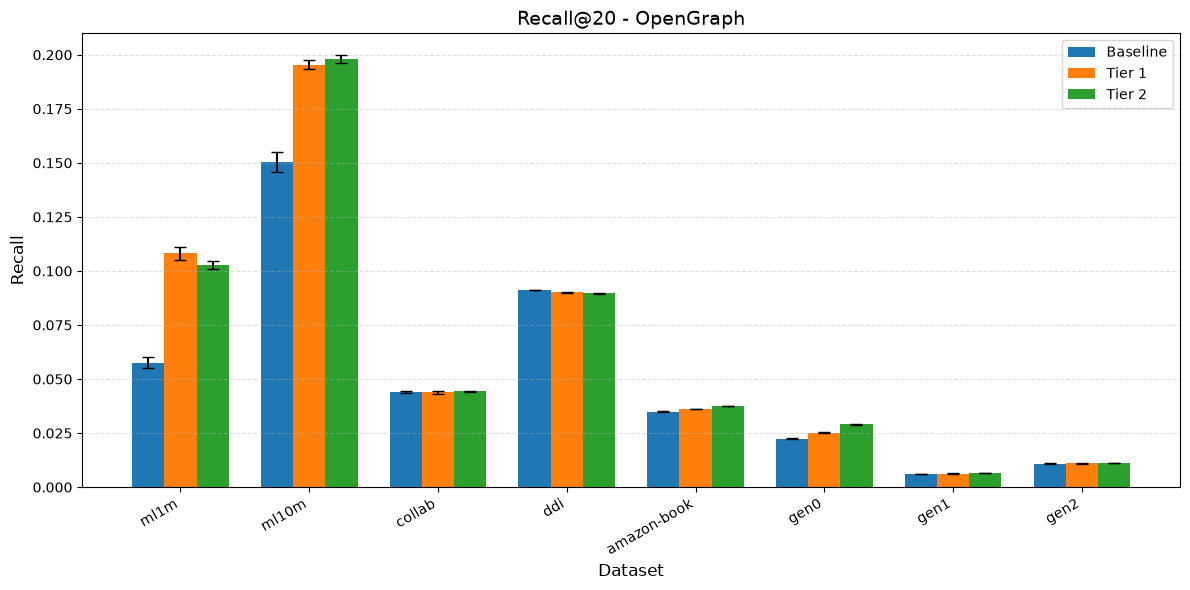

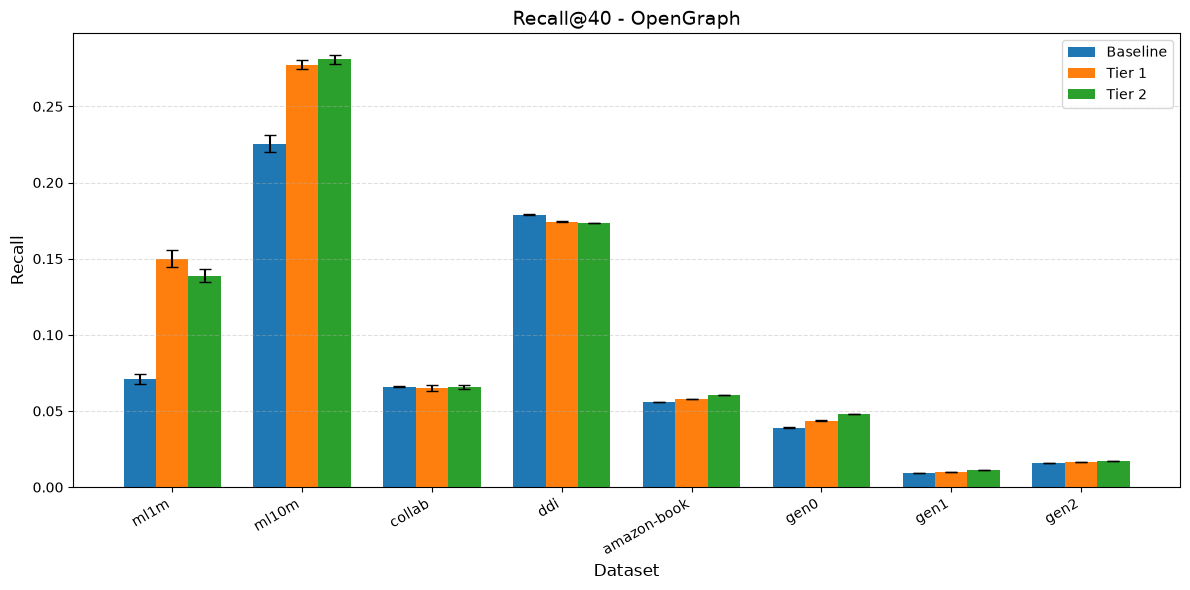

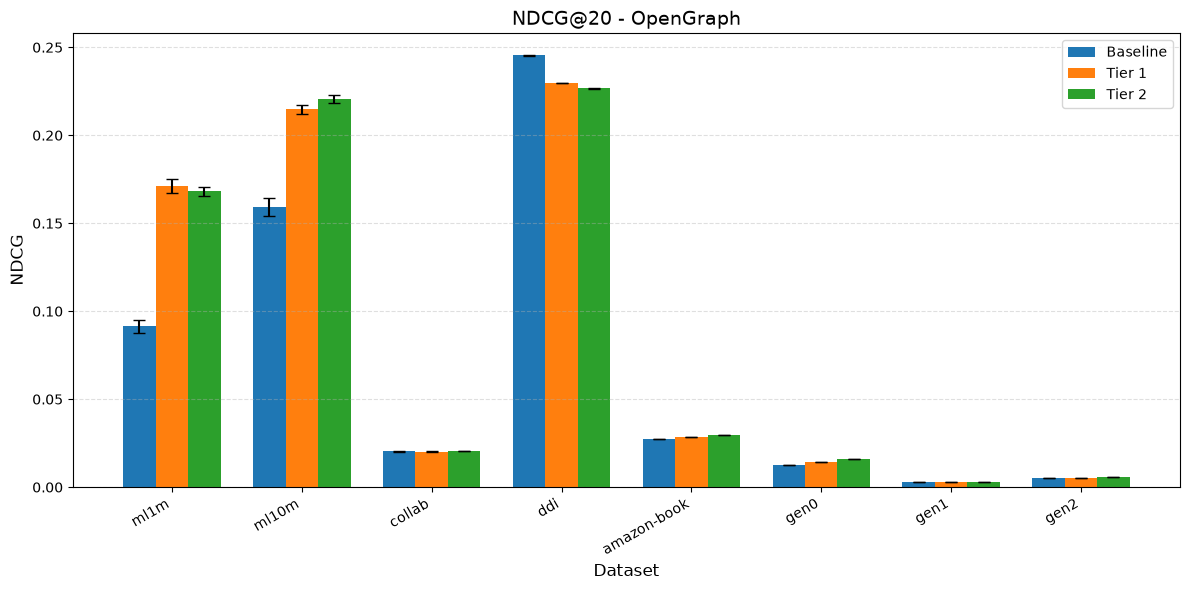

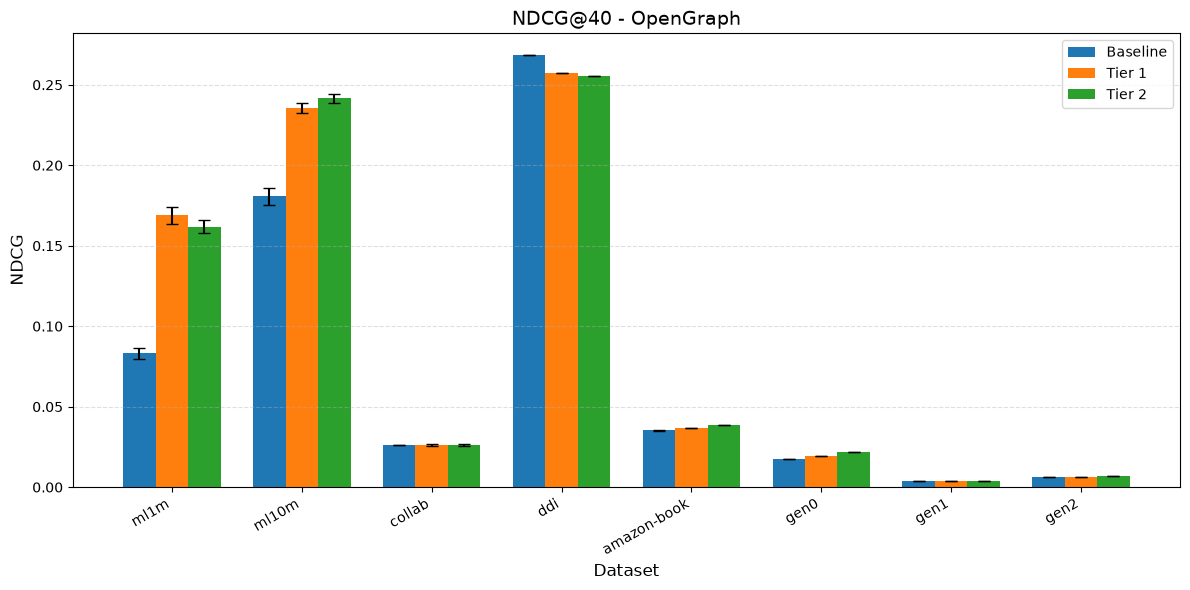

In [7]:
# ============================================================
# PREPARAR DADOS
# ============================================================

df = pd.read_csv("C:\\Mestrado\\Graph_Pruning\\Block_Influence_results\\layer_pruning_evaluation\\layer_pruning_link_prediction_pretrn_gen2.csv")

configuracoes = [
    "Baseline",
    "Tier 1",
    "Tier 2"
]

datasets = df["Dataset"].unique()

# Ordem desejada
df["Configuração"] = pd.Categorical(
    df["Configuração"],
    categories=configuracoes,
    ordered=True
)

df = df.sort_values(
    ["Dataset", "N", "Configuração"]
)


# ============================================================
# GERAR OS 4 GRÁFICOS
# ============================================================

plot_metric(
    df,
    "Recall",
    20
)

plot_metric(
    df,
    "Recall",
    40
)

plot_metric(
    df,
    "NDCG",
    20
)

plot_metric(
    df,
    "NDCG",
    40
)